<a href="https://colab.research.google.com/github/gurram-rohith/MDS-LAB/blob/main/Handling%20missing%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
df = pd.read_csv('/content/openpowerlifting.csv')

In [33]:

display(df)

,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386409,8481,William Barabas,M,Multi-ply,NaN,Elite,113.58,125,NaN,NaN,NaN,NaN,NaN,347.50,347.50,2,202.60
386410,8481,Justin Zottl,M,Multi-ply,NaN,Elite,119.02,125,NaN,NaN,NaN,NaN,NaN,322.50,322.50,3,185.77
386411,8481,Jake Anderson,M,Multi-ply,NaN,Elite,120.29,125,NaN,NaN,NaN,NaN,NaN,367.50,367.50,1,211.17
386412,8481,Jeff Bumanglag,M,Multi-ply,NaN,Elite,126.73,140,NaN,NaN,NaN,NaN,NaN,320.00,320.00,3,181.85


In [34]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values per column:")
display(missing_values)

Missing values per column:


,0
Squat4Kg,385171
Bench4Kg,384452
Deadlift4Kg,383614
Age,239267
BestSquatKg,88343
BestDeadliftKg,68567
BestBenchKg,30050
Wilks,24220
TotalKg,23177
Division,15843


In [35]:
# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Percentage of missing values per column:")
display(missing_percentage)

Percentage of missing values per column:


,0
Squat4Kg,99.678324
Bench4Kg,99.492254
Deadlift4Kg,99.275389
Age,61.919858
BestSquatKg,22.862267
BestDeadliftKg,17.744440
BestBenchKg,7.776633
Wilks,6.267889
TotalKg,5.997971
Division,4.100007


In [36]:
# Drop columns with more than 50% missing values
threshold = 50
columns_to_drop = missing_percentage[missing_percentage > threshold].index.tolist()
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with more than {threshold}% missing values: {columns_to_drop}")

# Recheck missing values after dropping columns
remaining_missing = df_cleaned.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("\nRemaining missing values per column:")
display(remaining_missing)

Dropped 4 columns with more than 50% missing values: ['Squat4Kg', 'Bench4Kg', 'Deadlift4Kg', 'Age']

Remaining missing values per column:


,0
BestSquatKg,88343
BestDeadliftKg,68567
BestBenchKg,30050
Wilks,24220
TotalKg,23177
Division,15843
WeightClassKg,3812
BodyweightKg,2402
Place,1092


In [37]:
# Fill remaining missing values

# Identify numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Impute numerical columns with the median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Impute categorical columns with the mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# Verify no more missing values
print("\nMissing values after imputation:")
display(df_cleaned.isnull().sum().sum())


Missing values after imputation:


np.int64(0)

In [38]:
display(df_cleaned.head())

,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,Mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,Open Senior,58.51,60,174.63,95.25,195.00,95.25,1,108.29
4,0,Destiny Dula,F,Raw,Teen 18-19,63.68,67.5,174.63,31.75,90.72,122.47,1,130.47


## Understanding `.loc` and `.iloc` for Data Selection

In pandas, `.loc` and `.iloc` are primary methods for indexing and selecting data from a DataFrame or Series. They offer powerful and flexible ways to access specific rows, columns, or subsets of data.

### `.loc` (Label-based indexing)

*   **Definition**: `.loc` is primarily label-based. This means you select data using the labels (names) of the rows and columns.
*   **Usage**: It requires row labels and column labels. You can pass single labels, lists of labels, slices of labels, or boolean arrays.
*   **Key Feature**: The end point of a slice with `.loc` is **inclusive**.
*   **Example**: `df.loc[row_label, column_label]`

### `.iloc` (Integer-location based indexing)

*   **Definition**: `.iloc` is primarily integer-location based. This means you select data using the integer positions (indices) of the rows and columns.
*   **Usage**: It requires integer positions for rows and columns. You can pass single integers, lists of integers, slices of integers, or boolean arrays.
*   **Key Feature**: The end point of a slice with `.iloc` is **exclusive** (similar to standard Python slicing).
*   **Example**: `df.iloc[row_position, column_position]`

In [39]:
# Demonstrating .loc (Label-based indexing)

print("--- Demonstrating .loc ---")

# 1. Selecting a single cell by row and column label
# Let's find the 'Name' of the person at index label 0
name_at_index_0 = df_cleaned.loc[0, 'Name']
print(f"\nName at row label 0: {name_at_index_0}")

# 2. Selecting a single row by its label
# Let's get the entire row for the first entry (label 0)
row_at_index_0 = df_cleaned.loc[0]
print("\nRow at label 0:")
display(row_at_index_0)

# 3. Selecting multiple columns for all rows
# (Equivalent to df[['Name', 'Sex']])
names_sex = df_cleaned.loc[:, ['Name', 'Sex']]
print("\nAll rows, 'Name' and 'Sex' columns (first 5 using .loc):")
display(names_sex.head())

# 4. Selecting a range of rows and specific columns by label
# Select rows from label 10 to label 15 (inclusive) and 'Name', 'TotalKg'
subset_loc = df_cleaned.loc[10:15, ['Name', 'TotalKg']]
print("\nRows 10 to 15 (inclusive) and 'Name', 'TotalKg' columns:")
display(subset_loc)

--- Demonstrating .loc ---

Name at row label 0: Angie Belk Terry

Row at label 0:


,0
MeetID,0
Name,Angie Belk Terry
Sex,F
Equipment,Wraps
Division,Mst 45-49
BodyweightKg,59.6
WeightClassKg,60
BestSquatKg,47.63
BestBenchKg,20.41
BestDeadliftKg,70.31



All rows, 'Name' and 'Sex' columns (first 5 using .loc):


,Name,Sex
0,Angie Belk Terry,F
1,Dawn Bogart,F
2,Dawn Bogart,F
3,Dawn Bogart,F
4,Destiny Dula,F



Rows 10 to 15 (inclusive) and 'Name', 'TotalKg' columns:


,Name,TotalKg
10,Kayce Hoover,340.20
11,Cindy Meeker,292.56
12,Cindy Meeker,292.56
13,Candice Pardue Maness,283.49
14,Danielle Ortiz,247.22
15,Jessica Jenkins,601.01


In [40]:
# Demonstrating .iloc (Integer-location based indexing)

print("--- Demonstrating .iloc ---")

# 1. Selecting a single cell by row and column position
# Let's find the 'Name' (which is the 1st column, so index 1) of the 0th row
# Note: column positions start from 0
name_at_pos_0 = df_cleaned.iloc[0, 1]
print(f"\nName at row position 0, column position 1: {name_at_pos_0}")

# 2. Selecting a single row by its integer position
# Get the entire row for the entry at position 5
row_at_pos_5 = df_cleaned.iloc[5]
print("\nRow at position 5:")
display(row_at_pos_5)

# 3. Selecting multiple columns for all rows by their integer positions
# 'Name' is index 1, 'Sex' is index 2
names_sex_iloc = df_cleaned.iloc[:, [1, 2]]
print("\nAll rows, columns at positions 1 and 2 (first 5 using .iloc):")
display(names_sex_iloc.head())

# 4. Selecting a range of rows and specific columns by integer position
# Select rows from position 20 up to (but not including) 25, and columns 'Name' (1) and 'TotalKg' (10)
subset_iloc = df_cleaned.iloc[20:25, [1, 10]]
print("\nRows 20 to 24 (exclusive) and columns at positions 1, 10:")
display(subset_iloc)

--- Demonstrating .iloc ---

Name at row position 0, column position 1: Angie Belk Terry

Row at position 5:


,5
MeetID,0
Name,Courtney Norris
Sex,F
Equipment,Wraps
Division,Open Senior
BodyweightKg,62.41
WeightClassKg,67.5
BestSquatKg,170.1
BestBenchKg,77.11
BestDeadliftKg,145.15



All rows, columns at positions 1 and 2 (first 5 using .iloc):


,Name,Sex
0,Angie Belk Terry,F
1,Dawn Bogart,F
2,Dawn Bogart,F
3,Dawn Bogart,F
4,Destiny Dula,F



Rows 20 to 24 (exclusive) and columns at positions 1, 10:


,Name,TotalKg
20,Alexis Eliopoulos,492.14
21,Shannon Nash,165.56
22,Paula Bowers,215.46
23,Kevin Gingerich,453.59
24,Juan Bollo,478.54


In [41]:
present_values=df.notnull().sum()
print("Present values per column:")
display(present_values)

Present values per column:


,0
MeetID,386414
Name,386414
Sex,386414
Equipment,386414
Age,147147
Division,370571
BodyweightKg,384012
WeightClassKg,382602
Squat4Kg,1243
BestSquatKg,298071


In [42]:
# Create a copy of the original DataFrame to demonstrate mean imputation
df_mean_imputed = df.copy()

# Identify numerical columns for mean imputation
numerical_cols_for_mean = df_mean_imputed.select_dtypes(include=['number']).columns

print("Numerical columns identified for mean imputation:")
display(list(numerical_cols_for_mean))

Numerical columns identified for mean imputation:


['MeetID',
 'Age',
 'BodyweightKg',
 'Squat4Kg',
 'BestSquatKg',
 'Bench4Kg',
 'BestBenchKg',
 'Deadlift4Kg',
 'BestDeadliftKg',
 'TotalKg',
 'Wilks']

In [43]:
# Fill missing values in numerical columns with the mean
for col in numerical_cols_for_mean:
    if df_mean_imputed[col].isnull().any():
        col_mean = df_mean_imputed[col].mean()
        df_mean_imputed[col] = df_mean_imputed[col].fillna(col_mean)
        print(f"Filled missing values in column '{col}' with mean: {col_mean:.2f}")

print("\nMissing values after mean imputation (numerical columns only):")
display(df_mean_imputed.isnull().sum()[df_mean_imputed.isnull().sum() > 0])

Filled missing values in column 'Age' with mean: 31.67
Filled missing values in column 'BodyweightKg' with mean: 86.93
Filled missing values in column 'Squat4Kg' with mean: 107.04
Filled missing values in column 'BestSquatKg' with mean: 176.57
Filled missing values in column 'Bench4Kg' with mean: 45.72
Filled missing values in column 'BestBenchKg' with mean: 118.35
Filled missing values in column 'Deadlift4Kg' with mean: 113.60
Filled missing values in column 'BestDeadliftKg' with mean: 195.04
Filled missing values in column 'TotalKg' with mean: 424.00
Filled missing values in column 'Wilks' with mean: 301.08

Missing values after mean imputation (numerical columns only):


,0
Division,15843
WeightClassKg,3812
Place,1092


In [44]:
display(df_mean_imputed.head())

,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,107.036404,47.630000,45.722905,20.41,113.597193,70.310000,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,107.036404,142.880000,45.722905,95.25,113.597193,163.290000,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,107.036404,142.880000,45.722905,95.25,113.597193,163.290000,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,107.036404,176.569941,45.722905,95.25,113.597193,195.040633,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,107.036404,176.569941,45.722905,31.75,113.597193,90.720000,122.47,1,130.47


## Data Transformation with `apply()` and `map()`

### Using `apply()` for Series and DataFrame Transformations

The `apply()` method can be used on a pandas Series or DataFrame to apply a function along an axis of the DataFrame. It is more general and can handle more complex operations than `map()`.

**1. `apply()` on a Series (Element-wise or Series-wise function)**

When called on a Series, `apply()` passes each element (if the function is element-wise) or the entire Series (if the function is designed to operate on a Series) to the specified function. Let's convert `BodyweightKg` to `BodyweightPounds` using `apply` and a lambda function.

In [45]:
# Example: Apply a function to a Series
# Convert BodyweightKg to BodyweightPounds (1 Kg = 2.20462 pounds)
df['BodyweightPounds'] = df['BodyweightKg'].apply(lambda x: x * 2.20462)

print("Original BodyweightKg (first 5 rows):")
display(df[['BodyweightKg']].head())

print("\nTransformed BodyweightPounds (first 5 rows):")
display(df[['BodyweightPounds']].head())

Original BodyweightKg (first 5 rows):


,BodyweightKg
0,59.60
1,58.51
2,58.51
3,58.51
4,63.68



Transformed BodyweightPounds (first 5 rows):


,BodyweightPounds
0,131.395352
1,128.992316
2,128.992316
3,128.992316
4,140.390202


**2. `apply()` on a DataFrame (Row-wise or Column-wise function)**

When called on a DataFrame, `apply()` can apply a function along either axis (rows or columns). By default, it applies column-wise (`axis=0`). If you want to apply row-wise, you specify `axis=1`.

In [46]:
# Example: Apply a function row-wise on a DataFrame
# Let's create a simplified DataFrame for demonstration involving 'BestSquatKg' and 'BestDeadliftKg'
# We'll calculate a 'TotalLift' for these two, but first handle potential NaNs by filling with 0 for this specific calculation

df_temp = df[['BestSquatKg', 'BestDeadliftKg']].fillna(0).head(10).copy()

def calculate_total_lift(row):
    return row['BestSquatKg'] + row['BestDeadliftKg']

df_temp['TotalLift'] = df_temp.apply(calculate_total_lift, axis=1)

print("DataFrame with row-wise application (TotalLift):")
display(df_temp)

DataFrame with row-wise application (TotalLift):


,BestSquatKg,BestDeadliftKg,TotalLift
0,47.63,70.31,117.94
1,142.88,163.29,306.17
2,142.88,163.29,306.17
3,0.00,0.00,0.00
4,0.00,90.72,90.72
5,170.10,145.15,315.25
6,124.74,163.29,288.03
7,124.74,163.29,288.03
8,120.20,108.86,229.06
9,0.00,108.86,108.86


### Using `map()` for Series Element-wise Transformations

The `map()` method is designed specifically for **Series** and is used for element-wise mapping of values. It's particularly useful for substituting each value in a Series with another value, often based on a dictionary or a function.

Let's use the 'Sex' column to map 'M' to 'Male' and 'F' to 'Female'.

In [47]:
# Example: Map values in a Series using a dictionary
sex_mapping = {'M': 'Male', 'F': 'Female'}
df['Sex_Full'] = df['Sex'].map(sex_mapping)

print("Original Sex column (first 5 rows):")
display(df[['Sex']].head())

print("\nTransformed Sex_Full column (first 5 rows):")
display(df[['Sex_Full']].head())

Original Sex column (first 5 rows):


,Sex
0,F
1,F
2,F
3,F
4,F



Transformed Sex_Full column (first 5 rows):


,Sex_Full
0,Female
1,Female
2,Female
3,Female
4,Female


### Key Differences and When to Use Which:

*   **`map()`**: Primarily for **Series** (column) transformations. It's optimized for element-wise mapping where you want to substitute each value with another value, usually based on a dictionary, Series, or a function that takes a single scalar value. It's generally faster than `apply` for element-wise operations with a simple mapping.

*   **`apply()`**: More general and versatile. It can be used on both **Series** and **DataFrames**. For Series, it can apply element-wise functions (like `map`), but also functions that operate on the entire Series at once (e.g., calculating a moving average). For DataFrames, it can apply functions row-wise (`axis=1`) or column-wise (`axis=0`), allowing you to perform operations that involve multiple columns or rows in a custom way.

In summary, use `map()` for simple element-wise substitutions on a Series. Use `apply()` for more complex element-wise operations on a Series, or when you need to apply a function that considers multiple elements/columns/rows on a DataFrame.

## Outlier Detection and Filtering

Outliers are data points that significantly differ from other observations. They can arise due to measurement errors, data entry errors, or genuine but extreme variations in the data. Handling outliers is crucial because they can skew statistical analyses, impact model performance, and lead to misleading conclusions.

There are several methods to detect and filter outliers. We'll explore some common ones:

1.  **Visualization**: Box plots and scatter plots are effective for visually identifying outliers.
2.  **Statistical Methods**: Such as the Z-score method and the Interquartile Range (IQR) method.

Let's use the `TotalKg` column from our `df_cleaned` DataFrame for demonstration, as it represents a numerical measure that might contain extreme values.

### 1. Visualizing Outliers with Box Plots

A box plot (or box-and-whisker plot) displays the distribution of a dataset. It shows the median, quartiles, and potential outliers as individual points beyond the 'whiskers'. Whiskers typically extend to 1.5 times the Interquartile Range (IQR) from the first and third quartiles.

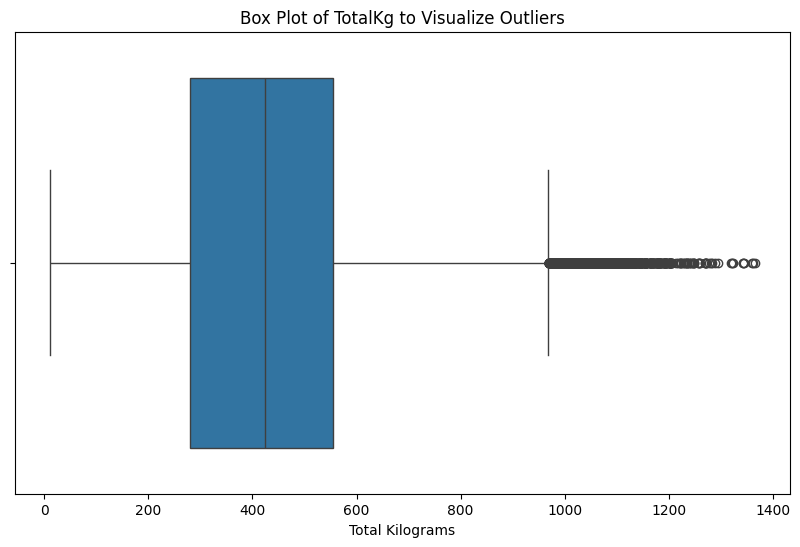

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_cleaned['TotalKg'])
plt.title('Box Plot of TotalKg to Visualize Outliers')
plt.xlabel('Total Kilograms')
plt.show()

### 2. Outlier Detection using Z-score Method

The Z-score method assumes that the data is normally distributed. A Z-score measures how many standard deviations an element is from the mean. A common threshold for identifying outliers is a Z-score absolute value greater than 2, 2.5, or 3. Here, we'll use a threshold of 3.

Formula: $Z = (X - \mu) / \sigma$

In [49]:
from scipy.stats import zscore
import numpy as np

# Calculate Z-scores for 'TotalKg'
# We need to exclude NaN values if any, although df_cleaned should not have them
z_scores = np.abs(zscore(df_cleaned['TotalKg']))

# Define a threshold for outliers
z_score_threshold = 3

# Identify outliers
outliers_zscore = df_cleaned[z_scores > z_score_threshold]

print(f"Number of outliers detected by Z-score method (threshold={z_score_threshold}): {len(outliers_zscore)}")
print("\nFirst 5 Z-score outliers:")
display(outliers_zscore.head())

Number of outliers detected by Z-score method (threshold=3): 1151

First 5 Z-score outliers:


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
53,0,Brian Hill,M,Multi-ply,Open Senior,107.50,110,455.86,288.03,315.25,1059.14,1,627.86
209,2,Brian Hill,M,Multi-ply,M-OFG-U,108.14,110,415.04,283.50,356.07,1054.60,1,623.96
407,5,Brian Hill,M,Multi-ply,Open,107.64,110,457.50,320.00,347.50,1125.00,1,666.62
421,5,Desi Hubbard,M,Multi-ply,Open,117.34,125,417.50,295.00,295.00,1007.50,1,582.37
429,5,TJ Watkins,M,Multi-ply,Open,154.18,140+,432.50,347.50,352.50,1132.50,1,624.18


### 3. Outlier Detection using IQR Method

The Interquartile Range (IQR) method is generally more robust to skewed distributions than the Z-score method. It defines outliers as values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

Formula:
*   $IQR = Q3 - Q1$
*   Lower Bound = $Q1 - 1.5 * IQR$
*   Upper Bound = $Q3 + 1.5 * IQR$

In [50]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_cleaned['TotalKg'].quantile(0.25)
Q3 = df_cleaned['TotalKg'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df_cleaned[(df_cleaned['TotalKg'] < lower_bound) | (df_cleaned['TotalKg'] > upper_bound)]

print(f"Number of outliers detected by IQR method (1.5*IQR rule): {len(outliers_iqr)}")
print("\nFirst 5 IQR outliers:")
display(outliers_iqr.head())

Number of outliers detected by IQR method (1.5*IQR rule): 1494

First 5 IQR outliers:


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
53,0,Brian Hill,M,Multi-ply,Open Senior,107.50,110,455.86,288.03,315.25,1059.14,1,627.86
209,2,Brian Hill,M,Multi-ply,M-OFG-U,108.14,110,415.04,283.50,356.07,1054.60,1,623.96
407,5,Brian Hill,M,Multi-ply,Open,107.64,110,457.50,320.00,347.50,1125.00,1,666.62
421,5,Desi Hubbard,M,Multi-ply,Open,117.34,125,417.50,295.00,295.00,1007.50,1,582.37
429,5,TJ Watkins,M,Multi-ply,Open,154.18,140+,432.50,347.50,352.50,1132.50,1,624.18


### Filtering Outliers

Once outliers are detected, you can choose to filter them out or treat them in other ways (e.g., winsorization, transformation). Here's how you can filter them out using the IQR method as an example:

In [51]:
# Create a DataFrame without the IQR outliers
df_filtered = df_cleaned[(df_cleaned['TotalKg'] >= lower_bound) & (df_cleaned['TotalKg'] <= upper_bound)]
print(f"Original DataFrame shape: {df_cleaned.shape}")
print(f"Filtered DataFrame shape (after removing IQR outliers): {df_filtered.shape}")

print("\nFirst 5 rows of the filtered DataFrame:")
display(df_filtered)

Original DataFrame shape: (386414, 13)
Filtered DataFrame shape (after removing IQR outliers): (384920, 13)

First 5 rows of the filtered DataFrame:


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,Mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,Open Senior,58.51,60,174.63,95.25,195.00,95.25,1,108.29
4,0,Destiny Dula,F,Raw,Teen 18-19,63.68,67.5,174.63,31.75,90.72,122.47,1,130.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
386409,8481,William Barabas,M,Multi-ply,Elite,113.58,125,174.63,115.00,347.50,347.50,2,202.60
386410,8481,Justin Zottl,M,Multi-ply,Elite,119.02,125,174.63,115.00,322.50,322.50,3,185.77
386411,8481,Jake Anderson,M,Multi-ply,Elite,120.29,125,174.63,115.00,367.50,367.50,1,211.17
386412,8481,Jeff Bumanglag,M,Multi-ply,Elite,126.73,140,174.63,115.00,320.00,320.00,3,181.85


## SQL Operations using Pandas

Pandas provides powerful functionalities that allow you to perform many common SQL operations directly on DataFrames. This is incredibly useful for data manipulation and analysis, especially when working with tabular data.

We will use the `df_cleaned` DataFrame for these demonstrations, as it's our cleaned dataset.

### 1. `SELECT` equivalent (Column Selection)

In SQL, you use `SELECT column1, column2 FROM table` to choose specific columns. In pandas, you can achieve this by passing a list of column names to your DataFrame.

In [52]:
# SQL: SELECT Name, Sex, TotalKg FROM df_cleaned
selected_columns = df_cleaned[['Name', 'Sex', 'TotalKg']]
print("Selected columns (first 5 rows):")
display(selected_columns.head())

Selected columns (first 5 rows):


,Name,Sex,TotalKg
0,Angie Belk Terry,F,138.35
1,Dawn Bogart,F,401.42
2,Dawn Bogart,F,401.42
3,Dawn Bogart,F,95.25
4,Destiny Dula,F,122.47


### 2. `WHERE` equivalent (Row Filtering)

SQL's `WHERE` clause is used to filter rows based on specified conditions. In pandas, you can use boolean indexing to filter rows.

In [53]:
# SQL: SELECT * FROM df_cleaned WHERE Sex = 'F' AND TotalKg > 400
filtered_df = df_cleaned[(df_cleaned['Sex'] == 'F') & (df_cleaned['TotalKg'] > 400)]
print("Filtered data (Female lifters with TotalKg > 400, first 5 rows):")
display(filtered_df.head())

Filtered data (Female lifters with TotalKg > 400, first 5 rows):


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
15,0,Jessica Jenkins,F,Multi-ply,Open Senior,80.56,82.5,229.06,161.03,210.92,601.01,1,547.81
20,0,Alexis Eliopoulos,F,Wraps,Senior,88.36,90,174.63,122.47,195.04,492.14,1,428.59
155,2,Courtney Guerrieri,F,Raw,F-OFR-U,65.41,67.5,163.29,90.72,158.76,412.77,1,431.03


### 3. `GROUP BY` and Aggregation equivalent

SQL's `GROUP BY` clause groups rows that have the same values in specified columns into summary rows, typically with aggregate functions like `COUNT`, `SUM`, `AVG`, `MIN`, `MAX`. Pandas uses the `groupby()` method followed by an aggregation function.

In [54]:
# SQL: SELECT Sex, AVG(TotalKg) FROM df_cleaned GROUP BY Sex
aggregated_df = df_cleaned.groupby('Sex')['TotalKg'].mean().reset_index()
aggregated_df.rename(columns={'TotalKg': 'AverageTotalKg'}, inplace=True)
print("Average TotalKg by Sex:")
display(aggregated_df)

Average TotalKg by Sex:


,Sex,AverageTotalKg
0,F,282.505880
1,M,465.347756


### 4. `ORDER BY` equivalent (Sorting Data)

SQL's `ORDER BY` clause sorts the result set. In pandas, `sort_values()` is used for this purpose.

In [55]:
# SQL: SELECT Name, TotalKg FROM df_cleaned ORDER BY TotalKg DESC LIMIT 5
sorted_df = df_cleaned[['Name', 'TotalKg']].sort_values(by='TotalKg', ascending=False)
print("Top 5 lifters by TotalKg:")
display(sorted_df.head())

Top 5 lifters by TotalKg:


,Name,TotalKg
57011,Dave Hoff,1365.31
53198,Dave Hoff,1363.05
162480,Donnie Thompson,1360.78
55694,Dave Hoff,1344.90
164936,Dave Hoff,1342.63


### 5. `JOIN` equivalent (Merging DataFrames)

SQL's `JOIN` clause combines rows from two or more tables based on a related column between them. In pandas, the `merge()` function performs similar operations.

In [56]:
# For demonstration, let's create a small 'meets' DataFrame
meets_data = {
    'MeetID': df_cleaned['MeetID'].unique()[:5], # Take first 5 unique MeetIDs
    'MeetLocation': ['USA', 'UK', 'Canada', 'Germany', 'Australia']
}
meets_df = pd.DataFrame(meets_data)

print("Original Meets DataFrame:")
display(meets_df.head())

# SQL: SELECT d.*, m.MeetLocation FROM df_cleaned d JOIN meets_df m ON d.MeetID = m.MeetID
merged_df = pd.merge(df_cleaned.head(10), meets_df, on='MeetID', how='inner')

print("\nMerged DataFrame (first 5 rows from df_cleaned joined with meets_df):")
display(merged_df[['Name', 'MeetID', 'MeetLocation', 'TotalKg']].head())

Original Meets DataFrame:


,MeetID,MeetLocation
0,0,USA
1,1,UK
2,2,Canada
3,3,Germany
4,4,Australia



Merged DataFrame (first 5 rows from df_cleaned joined with meets_df):


,Name,MeetID,MeetLocation,TotalKg
0,Angie Belk Terry,0,USA,138.35
1,Dawn Bogart,0,USA,401.42
2,Dawn Bogart,0,USA,401.42
3,Dawn Bogart,0,USA,95.25
4,Destiny Dula,0,USA,122.47


### 6. `DISTINCT` equivalent (Unique Values)

SQL's `DISTINCT` keyword returns only distinct values. In pandas, you can use `.unique()` for a Series or `.drop_duplicates()` for a DataFrame.

In [57]:
# SQL: SELECT DISTINCT Sex FROM df_cleaned
unique_sex = df_cleaned['Sex'].unique()
print("Unique values in 'Sex' column:")
display(unique_sex)

# SQL: SELECT DISTINCT Sex, Equipment FROM df_cleaned
unique_sex_equipment = df_cleaned[['Sex', 'Equipment']].drop_duplicates()
print("\nUnique combinations of 'Sex' and 'Equipment':")
display(unique_sex_equipment.head())

Unique values in 'Sex' column:


array(['F', 'M'], dtype=object)


Unique combinations of 'Sex' and 'Equipment':


,Sex,Equipment
0,F,Wraps
1,F,Single-ply
3,F,Raw
15,F,Multi-ply
23,M,Raw


## SQL Operations using Pandas

Pandas provides powerful functionalities that allow you to perform many common SQL operations directly on DataFrames. This is incredibly useful for data manipulation and analysis, especially when working with tabular data.

We will use the `df_cleaned` DataFrame for these demonstrations, as it's our cleaned dataset.

### 1. `SELECT` equivalent (Column Selection)

In SQL, you use `SELECT column1, column2 FROM table` to choose specific columns. In pandas, you can achieve this by passing a list of column names to your DataFrame.

In [58]:
import pandas as pd
import numpy as np

# --- Recreating df and df_cleaned for robustness ---
# This section is added to ensure df_cleaned is available for the SQL operations
# in case previous cells were not run or the kernel was reset.

df = pd.read_csv('/content/openpowerlifting.csv')

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Drop columns with more than 50% missing values
threshold = 50
columns_to_drop = missing_percentage[missing_percentage > threshold].index.tolist()
df_cleaned = df.drop(columns=columns_to_drop)

# Identify numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Impute numerical columns with the median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Impute categorical columns with the mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
# --- End of df_cleaned recreation ---


# SQL: SELECT Name, Sex, TotalKg FROM df_cleaned
selected_columns = df_cleaned[['Name', 'Sex', 'TotalKg']]
print("Selected columns (first 5 rows):")
display(selected_columns.head())

Selected columns (first 5 rows):


,Name,Sex,TotalKg
0,Angie Belk Terry,F,138.35
1,Dawn Bogart,F,401.42
2,Dawn Bogart,F,401.42
3,Dawn Bogart,F,95.25
4,Destiny Dula,F,122.47


### 2. `WHERE` equivalent (Row Filtering)

SQL's `WHERE` clause is used to filter rows based on specified conditions. In pandas, you can use boolean indexing to filter rows.

In [59]:
# SQL: SELECT * FROM df_cleaned WHERE Sex = 'F' AND TotalKg > 400
filtered_df = df_cleaned[(df_cleaned['Sex'] == 'F') & (df_cleaned['TotalKg'] > 400)]
print("Filtered data (Female lifters with TotalKg > 400, first 5 rows):")
display(filtered_df.head())

Filtered data (Female lifters with TotalKg > 400, first 5 rows):


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
15,0,Jessica Jenkins,F,Multi-ply,Open Senior,80.56,82.5,229.06,161.03,210.92,601.01,1,547.81
20,0,Alexis Eliopoulos,F,Wraps,Senior,88.36,90,174.63,122.47,195.04,492.14,1,428.59
155,2,Courtney Guerrieri,F,Raw,F-OFR-U,65.41,67.5,163.29,90.72,158.76,412.77,1,431.03


### 3. `GROUP BY` and Aggregation equivalent

SQL's `GROUP BY` clause groups rows that have the same values in specified columns into summary rows, typically with aggregate functions like `COUNT`, `SUM`, `AVG`, `MIN`, `MAX`. Pandas uses the `groupby()` method followed by an aggregation function.

In [60]:
# SQL: SELECT Sex, AVG(TotalKg) FROM df_cleaned GROUP BY Sex
aggregated_df = df_cleaned.groupby('Sex')['TotalKg'].mean().reset_index()
aggregated_df.rename(columns={'TotalKg': 'AverageTotalKg'}, inplace=True)
print("Average TotalKg by Sex:")
display(aggregated_df)

Average TotalKg by Sex:


,Sex,AverageTotalKg
0,F,282.505880
1,M,465.347756


### 4. `ORDER BY` equivalent (Sorting Data)

SQL's `ORDER BY` clause sorts the result set. In pandas, `sort_values()` is used for this purpose.

In [61]:
# SQL: SELECT Name, TotalKg FROM df_cleaned ORDER BY TotalKg DESC LIMIT 5
sorted_df = df_cleaned[['Name', 'TotalKg']].sort_values(by='TotalKg', ascending=False)
print("Top 5 lifters by TotalKg:")
display(sorted_df.head())

Top 5 lifters by TotalKg:


,Name,TotalKg
57011,Dave Hoff,1365.31
53198,Dave Hoff,1363.05
162480,Donnie Thompson,1360.78
55694,Dave Hoff,1344.90
164936,Dave Hoff,1342.63


### 5. `JOIN` equivalent (Merging DataFrames)

SQL's `JOIN` clause combines rows from two or more tables based on a related column between them. In pandas, the `merge()` function performs similar operations.

In [62]:
import pandas as pd # Ensure pandas is imported for DataFrame creation

# For demonstration, let's create a small 'meets' DataFrame
meets_data = {
    'MeetID': df_cleaned['MeetID'].unique()[:5], # Take first 5 unique MeetIDs
    'MeetLocation': ['USA', 'UK', 'Canada', 'Germany', 'Australia']
}
meets_df = pd.DataFrame(meets_data)

print("Original Meets DataFrame:")
display(meets_df.head())

# SQL: SELECT d.*, m.MeetLocation FROM df_cleaned d JOIN meets_df m ON d.MeetID = m.MeetID
merged_df = pd.merge(df_cleaned.head(10), meets_df, on='MeetID', how='inner')

print("\nMerged DataFrame (first 5 rows from df_cleaned joined with meets_df):")
display(merged_df[['Name', 'MeetID', 'MeetLocation', 'TotalKg']].head())

Original Meets DataFrame:


,MeetID,MeetLocation
0,0,USA
1,1,UK
2,2,Canada
3,3,Germany
4,4,Australia



Merged DataFrame (first 5 rows from df_cleaned joined with meets_df):


,Name,MeetID,MeetLocation,TotalKg
0,Angie Belk Terry,0,USA,138.35
1,Dawn Bogart,0,USA,401.42
2,Dawn Bogart,0,USA,401.42
3,Dawn Bogart,0,USA,95.25
4,Destiny Dula,0,USA,122.47


### 6. `DISTINCT` equivalent (Unique Values)

SQL's `DISTINCT` keyword returns only distinct values. In pandas, you can use `.unique()` for a Series or `.drop_duplicates()` for a DataFrame.

In [63]:
# SQL: SELECT DISTINCT Sex FROM df_cleaned
unique_sex = df_cleaned['Sex'].unique()
print("Unique values in 'Sex' column:")
display(unique_sex)

# SQL: SELECT DISTINCT Sex, Equipment FROM df_cleaned
unique_sex_equipment = df_cleaned[['Sex', 'Equipment']].drop_duplicates()
print("\nUnique combinations of 'Sex' and 'Equipment':")
display(unique_sex_equipment.head())

Unique values in 'Sex' column:


array(['F', 'M'], dtype=object)


Unique combinations of 'Sex' and 'Equipment':


,Sex,Equipment
0,F,Wraps
1,F,Single-ply
3,F,Raw
15,F,Multi-ply
23,M,Raw


## Re-demonstrating SQL Operations using Pandas (Ensuring DataFrame Availability)

To ensure `df_cleaned` is available for all SQL-like operations, the necessary data loading and cleaning steps are included here. This makes the demonstration self-contained and robust to kernel resets.

In [64]:
import pandas as pd
import numpy as np

# --- Data Loading and Cleaning (ensuring df_cleaned is available) ---
# Load the dataset
df = pd.read_csv('/content/openpowerlifting.csv')

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Drop columns with more than 50% missing values
threshold = 50
columns_to_drop = missing_percentage[missing_percentage > threshold].index.tolist()
df_cleaned = df.drop(columns=columns_to_drop)

# Identify numerical and categorical columns for imputation
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Impute numerical columns with the median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Impute categorical columns with the mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("DataFrame `df_cleaned` has been successfully created and cleaned.")
print(f"Shape of df_cleaned: {df_cleaned.shape}")
display(df_cleaned.head())

DataFrame `df_cleaned` has been successfully created and cleaned.
Shape of df_cleaned: (386414, 13)


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,Mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,Open Senior,58.51,60,174.63,95.25,195.00,95.25,1,108.29
4,0,Destiny Dula,F,Raw,Teen 18-19,63.68,67.5,174.63,31.75,90.72,122.47,1,130.47


### 1. `SELECT` equivalent (Column Selection)

In SQL, you use `SELECT column1, column2 FROM table` to choose specific columns. In pandas, you can achieve this by passing a list of column names to your DataFrame.

In [65]:
# SQL: SELECT Name, Sex, TotalKg FROM df_cleaned
selected_columns = df_cleaned[['Name', 'Sex', 'TotalKg']]
print("Selected columns (first 5 rows):")
display(selected_columns.head())

Selected columns (first 5 rows):


,Name,Sex,TotalKg
0,Angie Belk Terry,F,138.35
1,Dawn Bogart,F,401.42
2,Dawn Bogart,F,401.42
3,Dawn Bogart,F,95.25
4,Destiny Dula,F,122.47


### 2. `WHERE` equivalent (Row Filtering)

SQL's `WHERE` clause is used to filter rows based on specified conditions. In pandas, you can use boolean indexing to filter rows.

In [66]:
# SQL: SELECT * FROM df_cleaned WHERE Sex = 'F' AND TotalKg > 400
filtered_df_sql_where = df_cleaned[(df_cleaned['Sex'] == 'F') & (df_cleaned['TotalKg'] > 400)]
print("Filtered data (Female lifters with TotalKg > 400, first 5 rows):")
display(filtered_df_sql_where.head())

Filtered data (Female lifters with TotalKg > 400, first 5 rows):


,MeetID,Name,Sex,Equipment,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
1,0,Dawn Bogart,F,Single-ply,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,Open Senior,58.51,60,142.88,95.25,163.29,401.42,1,456.38
15,0,Jessica Jenkins,F,Multi-ply,Open Senior,80.56,82.5,229.06,161.03,210.92,601.01,1,547.81
20,0,Alexis Eliopoulos,F,Wraps,Senior,88.36,90,174.63,122.47,195.04,492.14,1,428.59
155,2,Courtney Guerrieri,F,Raw,F-OFR-U,65.41,67.5,163.29,90.72,158.76,412.77,1,431.03


### 3. `GROUP BY` and Aggregation equivalent

SQL's `GROUP BY` clause groups rows that have the same values in specified columns into summary rows, typically with aggregate functions like `COUNT`, `SUM`, `AVG`, `MIN`, `MAX`. Pandas uses the `groupby()` method followed by an aggregation function.

In [67]:
# SQL: SELECT Sex, AVG(TotalKg) FROM df_cleaned GROUP BY Sex
aggregated_df_sql_groupby = df_cleaned.groupby('Sex')['TotalKg'].mean().reset_index()
aggregated_df_sql_groupby.rename(columns={'TotalKg': 'AverageTotalKg'}, inplace=True)
print("Average TotalKg by Sex:")
display(aggregated_df_sql_groupby)

Average TotalKg by Sex:


,Sex,AverageTotalKg
0,F,282.505880
1,M,465.347756


### 4. `ORDER BY` equivalent (Sorting Data)

SQL's `ORDER BY` clause sorts the result set. In pandas, `sort_values()` is used for this purpose.

In [68]:
# SQL: SELECT Name, TotalKg FROM df_cleaned ORDER BY TotalKg DESC LIMIT 5
sorted_df_sql_orderby = df_cleaned[['Name', 'TotalKg']].sort_values(by='TotalKg', ascending=False)
print("Top 5 lifters by TotalKg:")
display(sorted_df_sql_orderby.head())

Top 5 lifters by TotalKg:


,Name,TotalKg
57011,Dave Hoff,1365.31
53198,Dave Hoff,1363.05
162480,Donnie Thompson,1360.78
55694,Dave Hoff,1344.90
164936,Dave Hoff,1342.63


### 5. `JOIN` equivalent (Merging DataFrames)

SQL's `JOIN` clause combines rows from two or more tables based on a related column between them. In pandas, the `merge()` function performs similar operations.

In [69]:
# For demonstration, let's create a small 'meets' DataFrame
meets_data = {
    'MeetID': df_cleaned['MeetID'].unique()[:5], # Take first 5 unique MeetIDs
    'MeetLocation': ['USA', 'UK', 'Canada', 'Germany', 'Australia']
}
meets_df = pd.DataFrame(meets_data)

print("Original Meets DataFrame:")
display(meets_df.head())

# SQL: SELECT d.*, m.MeetLocation FROM df_cleaned d JOIN meets_df m ON d.MeetID = m.MeetID
merged_df_sql_join = pd.merge(df_cleaned.head(10), meets_df, on='MeetID', how='inner')

print("\nMerged DataFrame (first 5 rows from df_cleaned joined with meets_df):")
display(merged_df_sql_join[['Name', 'MeetID', 'MeetLocation', 'TotalKg']].head())

Original Meets DataFrame:


,MeetID,MeetLocation
0,0,USA
1,1,UK
2,2,Canada
3,3,Germany
4,4,Australia



Merged DataFrame (first 5 rows from df_cleaned joined with meets_df):


,Name,MeetID,MeetLocation,TotalKg
0,Angie Belk Terry,0,USA,138.35
1,Dawn Bogart,0,USA,401.42
2,Dawn Bogart,0,USA,401.42
3,Dawn Bogart,0,USA,95.25
4,Destiny Dula,0,USA,122.47


### 6. `DISTINCT` equivalent (Unique Values)

SQL's `DISTINCT` keyword returns only distinct values. In pandas, you can use `.unique()` for a Series or `.drop_duplicates()` for a DataFrame.

In [70]:
# SQL: SELECT DISTINCT Sex FROM df_cleaned
unique_sex_sql = df_cleaned['Sex'].unique()
print("Unique values in 'Sex' column:")
display(unique_sex_sql)

# SQL: SELECT DISTINCT Sex, Equipment FROM df_cleaned
unique_sex_equipment_sql = df_cleaned[['Sex', 'Equipment']].drop_duplicates()
print("\nUnique combinations of 'Sex' and 'Equipment':")
display(unique_sex_equipment_sql.head())

Unique values in 'Sex' column:


array(['F', 'M'], dtype=object)


Unique combinations of 'Sex' and 'Equipment':


,Sex,Equipment
0,F,Wraps
1,F,Single-ply
3,F,Raw
15,F,Multi-ply
23,M,Raw


## Resources

This section can be used to list relevant resources such as documentation, tutorials, datasets, or libraries that are useful for this notebook or related topics.